<a href="https://colab.research.google.com/github/eospgonz10/statistical_analytics_homicide/blob/main/sesiones_practicas/sp_4_juan_jose_garcia_alvarez_estiven_ospina_gonzalez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

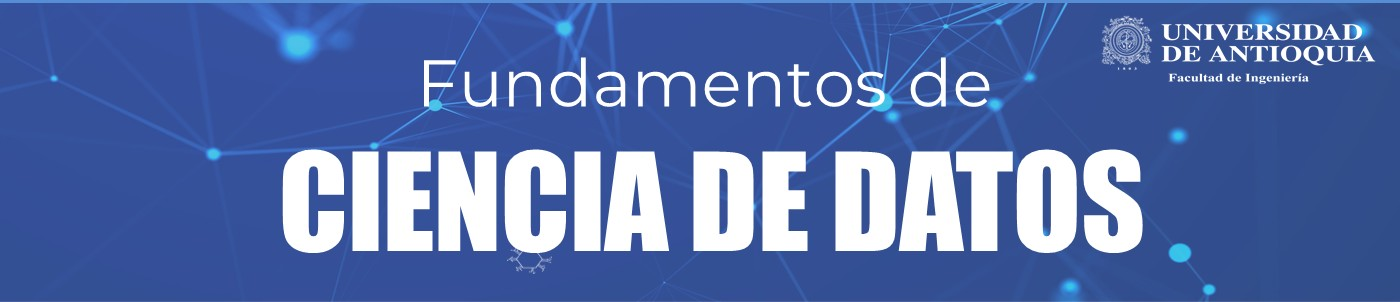

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>

## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Estiven Ospina González **CC** 1152711784

Juan José García Álvarez **CC** 1152226318

# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

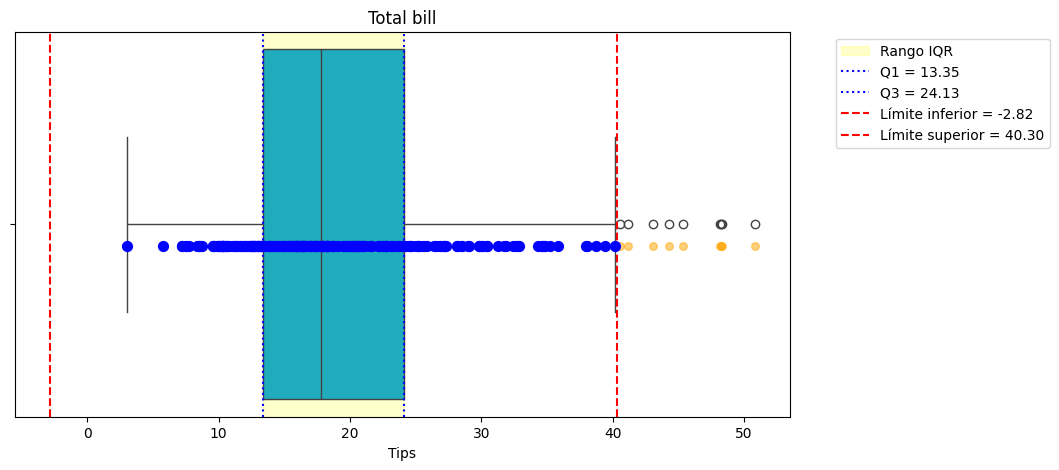

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(10,5))
sns.boxplot(x=total_bill, color="#06C1D6")
plt.scatter(data_a, [0.05]*len(data_a), color="orange", s=30, alpha=0.5)
plt.scatter(data_b, [0.05]*len(data_b), color="blue", s=50, zorder=5)

plt.axvspan(Q1, Q3, color='yellow', alpha=0.2, label='Rango IQR')
plt.axvline(Q1, color='blue', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='blue', linestyle=':', label=f'Q3 = {Q3:.2f}')
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite superior = {lim_sup:.2f}')

plt.xlabel('Tips')
plt.title('Total bill')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# **Analisis Ejercicio #1**

Existen pocas ventas particularmente altas que superen los 40 y lleguen hasta 50. Estos puntos aislados a la derecha representan consumos muy grandes, pero reales (que pueden ser mesas de muchas personas, por ejemplo) que traen picos de ingresos muy altos. Básicamente el negocio tiene un flujo de ventas base muy estable, pero se beneficia de compras extraordinarias ocasionales que no deben ignorarse ni descartarse.

# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

    tip   z_score     media  desv_est
0  1.01 -1.439947  2.998279    1.3808
1  1.66 -0.969205  2.998279    1.3808
2  3.50  0.363356  2.998279    1.3808
3  3.31  0.225754  2.998279    1.3808
4  3.61  0.443020  2.998279    1.3808
5  4.71  1.239659  2.998279    1.3808
6  2.00 -0.722971  2.998279    1.3808
7  3.12  0.088153  2.998279    1.3808
8  1.96 -0.751940  2.998279    1.3808
9  3.23  0.167817  2.998279    1.3808


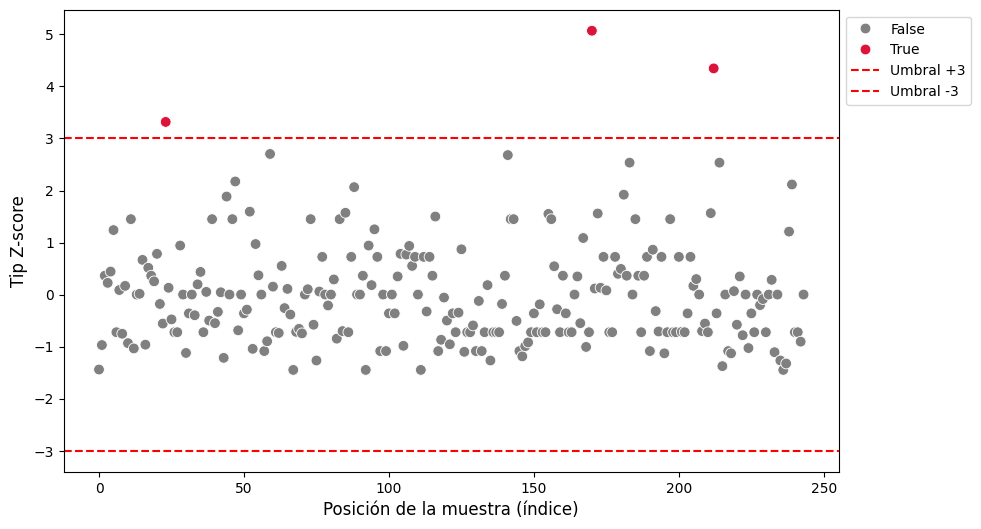

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

tips = sns.load_dataset("tips")
df = pd.DataFrame(tips)
df['z_score'] = zscore(df['tip'])
df['outlier_z'] = df['z_score'].abs() > 3

# Media y desviación estándar global
mu = df['tip'].mean()
sigma = df['tip'].std(ddof=0)

# Calcular z-score
df['z_score'] = (df['tip'] - mu) / sigma

# Mostrar n muestras
tabla_muestra = df[['tip', 'z_score']].head(10)
tabla_muestra['media'] = mu
tabla_muestra['desv_est'] = sigma
print(tabla_muestra)


# Crear scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(x=np.arange(len(df['z_score'])), y=df['z_score'], hue='outlier_z', data=df, palette={False: 'gray', True: 'crimson'}, s=60)

plt.axhline(y=3, color='red', linestyle='--', label='Umbral +3')
plt.axhline(y=-3, color='red', linestyle='--', label='Umbral -3')
plt.xlabel("Posición de la muestra (índice)", fontsize=12)
plt.ylabel("Tip Z-score", fontsize=12)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

# **Analísis Ejercicio #2**

Vemos que la gran mayoría de las propinas son estables, pero destacan 3 casos únicos que rompen el límite de +3 desviaciones estándar. Estos puntos representan propinas que se disparan hasta puntajes de 4 y 5, algo inusual comparado con el resto. Lo bueno es que no tienes valores atípicos negativos, lo que indica que no hay caídas críticas por debajo del umbral de -3. Es un escenario de consistencia total con tres excepciones.

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

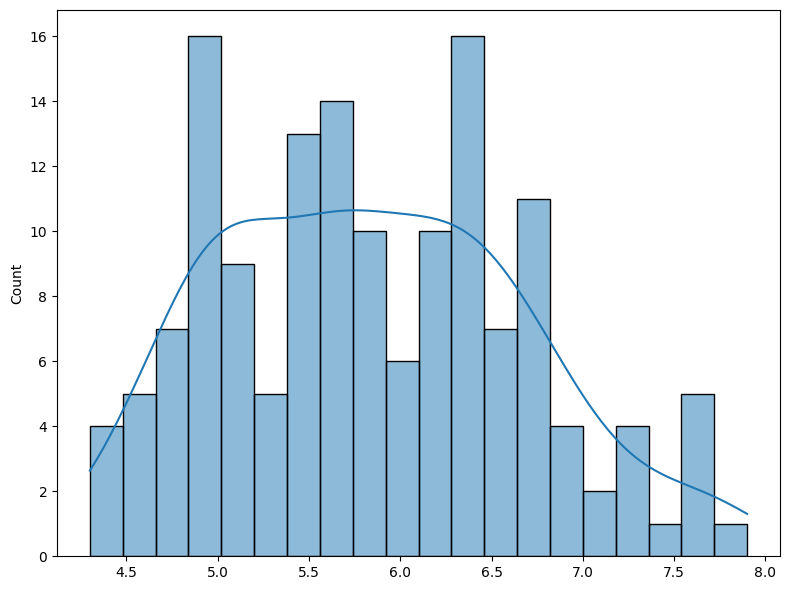

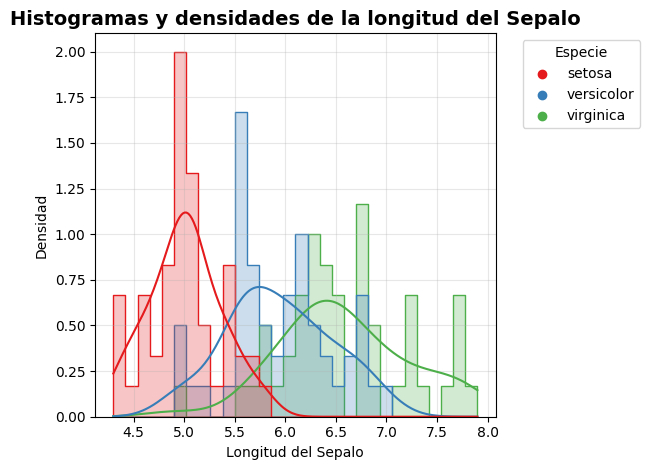

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values
species = iris["species"].unique()
palette = dict(zip(species, sns.color_palette("Set1", n_colors=len(species))))

plt.figure(figsize=(8,6))
sns.histplot(x=x, bins=20, kde=True)
plt.tight_layout()
plt.show()

# Histograma
ax = sns.histplot(
    data=iris,
    x="sepal_length",
    hue="species",
    kde=True,
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    palette=palette,
    legend=False
)

plt.title("Histogramas y densidades de la longitud del Sepalo", fontsize=14, weight="bold")
plt.xlabel("Longitud del Sepalo")
plt.ylabel("Densidad")

for sp in species:
    ax.scatter([], [], color=palette[sp], label=sp)

ax.legend(title="Especie", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# **Analísis Ejercicio #3**

La especie setosa muestra una distribución concentrada (aprox 4.8-5.2 cm) sin valores atípicos significativos. Por el contrario, versicolor presenta valores más dispersos con potenciales outliers leves en los extremos. Virginica exhibe la distribución más amplia con un probable outlier en la cola superior cercano a 8.0 cm. La separación clara entre especies sugiere que los outliers son valores de una especie que se solapan con otra, siendo menos relevante detectar anomalías dentro de cada grupo por separado.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10976/1490288677.py:28: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(mean_val + outlier_threshold*std_val, color="orange", linestyle=":", label=f"+\sigma {outlier_threshold}")
/tmp/ipykernel_10976/1490288677.py:29: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(mean_val - outlier_threshold*std_val, color="orange", linestyle=":", label=f"-\sigma {outlier_threshold}")


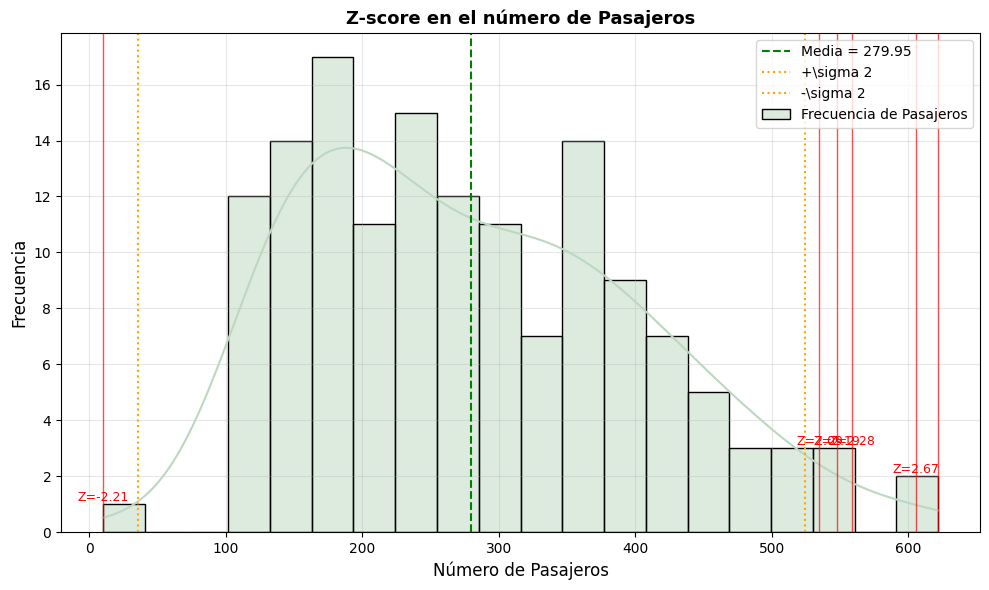

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

flights = sns.load_dataset("flights")
x = flights["passengers"].values
x = np.append(x, [10, 500])

data = x

plt.figure(figsize=(10, 6))

# Calcular Z-scores
z_scores = stats.zscore(data)

outlier_threshold = 2
outliers_data = data[np.abs(z_scores) > outlier_threshold]
outliers_z = z_scores[np.abs(z_scores) > outlier_threshold]

# Histograma
sns.histplot(data, bins=20, kde=True, color='#bcd8bf', label='Frecuencia de Pasajeros')

# Líneas de referencia para la media y desviaciones estándar
mean_val = np.mean(data)
std_val = np.std(data)
plt.axvline(mean_val, color="green", linestyle="--", label=f"Media = {mean_val:.2f}")
plt.axvline(mean_val + outlier_threshold*std_val, color="orange", linestyle=":", label=f"+\sigma {outlier_threshold}")
plt.axvline(mean_val - outlier_threshold*std_val, color="orange", linestyle=":", label=f"-\sigma {outlier_threshold}")

# Outliers con anotación de Z-score
n, bins, patches = plt.gca().hist(data, bins=20, alpha=0)

for out_val, z_val in zip(outliers_data, outliers_z):
    bin_idx = np.digitize(out_val, bins) - 1
    if bin_idx < len(n):
        y_pos = n[bin_idx] if n[bin_idx] > 0 else plt.gca().get_ylim()[1]
        plt.text(out_val, y_pos, f"Z={z_val:.2f}", color="red", fontsize=9, ha='center', va='bottom')
    plt.axvline(out_val, color="red", linestyle="-", linewidth=1, alpha=0.7)

plt.title(f"Z-score en el número de Pasajeros", fontsize=13, weight="bold")
plt.xlabel("Número de Pasajeros", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **Analísis Ejercicio#5**

Identificamos una distribución concentrada alrededor de 280 pasajeros con densidad máxima entre 150-250. Se detectan cuatro outliers con |Z-score| > 2: dos valores extremadamente bajos (Z≈-2.21 con 10 pasajeros y Z≈-2.03) representando posibles registros defectuosos o vuelos cancelados, y dos valores altos (Z≈-2.03D28 y Z=2.67 con más de 500 pasajeros) que superan la demanda típica. La simetría del método Z-score permite identificar ambas colas de la distribución, siendo el umbral ±2σ bastante sensible para detectar anomalías, aunque esto requiere validación contextual para distinguir entre errores reales y comportamientos legítimos.

# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

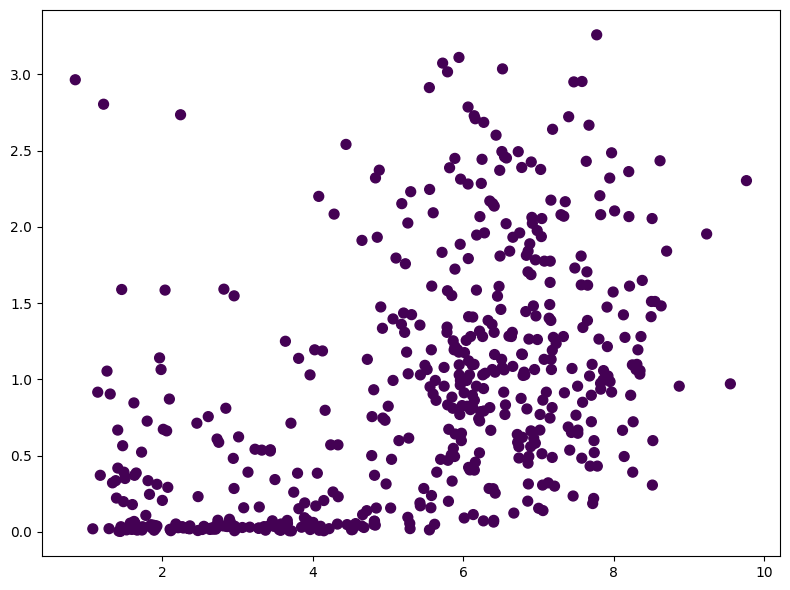

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X)

kmeans = KMeans(n_clusters=1, random_state=42).fit(X)
labels = kmeans.labels_

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=50)
plt.tight_layout()
plt.show()
